In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import math
from smalldiffusion import Swissroll
import numpy as np
import matplotlib.pyplot as plt

c:\Users\dzluk\Syrinx\audio-diffusion-course\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class Schedule:
    def __init__(self, sigmas: torch.FloatTensor):
        self.sigmas = sigmas
    def __getitem__(self, i) -> torch.FloatTensor:
        return self.sigmas[i]
    def __len__(self) -> int:
        return len(self.sigmas)
    def sample_batch(self, x0:torch.FloatTensor) -> torch.FloatTensor:
        return self[torch.randint(len(self), (x0.shape[0],))].to(x0)
    def sample_sigmas(self, steps: int) -> torch.FloatTensor:
        indices = list((len(self) * (1 - np.arange(0, steps)/steps))
                       .round().astype(np.int64) - 1)
        return self[indices + [0]]

class ScheduleLogLinear(Schedule):
    def __init__(self, N: int, sigma_min: float=0.02, sigma_max: float=10):
        super().__init__(torch.logspace(math.log10(sigma_min), math.log10(sigma_max), N))


def generate_train_sample(x0: torch.FloatTensor, schedule: Schedule):
    sigma = schedule.sample_batch(x0)
    eps = torch.randn_like(x0)
    return sigma, eps


def training_loop(loader  : DataLoader,
                  model   : nn.Module,
                  schedule: Schedule,
                  epochs  : int = 10000):
    losses = []
    optimizer = torch.optim.Adam(model.parameters())
    for _ in range(epochs):
        for x0 in loader:
            optimizer.zero_grad()
            # sigma is the amount of noise (as determined by the schedule)
            # eps is the actual noise
            sigma, eps = generate_train_sample(x0, schedule)
            mult = sigma.unsqueeze(1) * eps
            sum = x0 + mult

            eps_hat = model(sum, sigma)
            loss = nn.MSELoss()(eps_hat, eps)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
    return model, losses


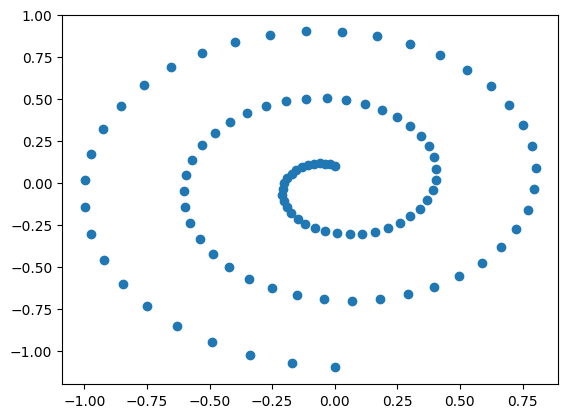

In [3]:
dataset = Swissroll(np.pi/2, 5*np.pi, 100)
loader = DataLoader(dataset, batch_size=2048)

plt.scatter(*dataset[:100].T)

In [4]:
from itertools import pairwise

def get_sigma_embeds(sigma):
    sigma = sigma.unsqueeze(1)
    return torch.cat([torch.sin(torch.log(sigma)/2),
                      torch.cos(torch.log(sigma)/2)], dim=1)

# Denoiser is an MLP instead of a U-Net
class TimeInputMLP(nn.Module):
    def __init__(self, dim, hidden_dims):
        super().__init__()
        layers = []
        for in_dim, out_dim in pairwise((dim + 2,) + hidden_dims):
            layers.extend([nn.Linear(in_dim, out_dim), nn.GELU()])
        layers.append(nn.Linear(hidden_dims[-1], dim))
        self.net = nn.Sequential(*layers)
        self.input_dims = (dim,)

    def rand_input(self, batchsize):
        return torch.randn((batchsize,) + self.input_dims)

    def forward(self, x, sigma):
        # predict the noise given the noisy input and the noise level (sigma)
        # sigma can be thought of as the timestep, where higher sigma means more noise
        sigma_embeds = get_sigma_embeds(sigma)         # shape: b x 2
        nn_input = torch.cat([x, sigma_embeds], dim=1) # shape: b x (dim + 2)
        return self.net(nn_input)

model = TimeInputMLP(dim=2, hidden_dims=(16,128,128,128,128,16))

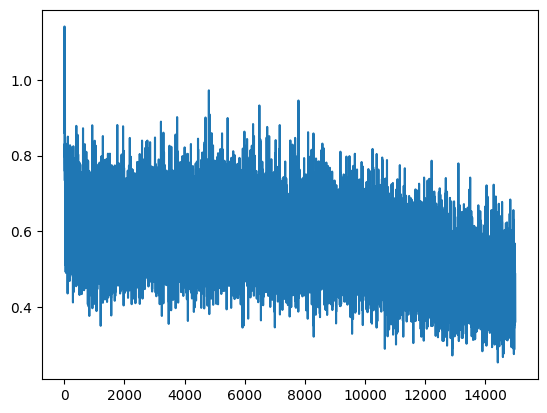

In [5]:
schedule = ScheduleLogLinear(N=200, sigma_min=0.005, sigma_max=10)
trained_model, losses  = training_loop(loader, model, schedule, epochs=15000)
plt.plot(losses)

torch.Size([2000, 2])


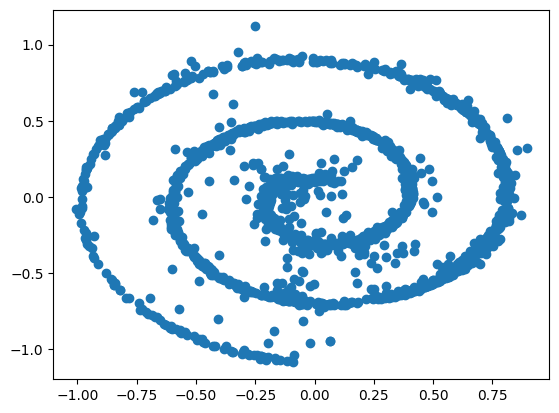

In [6]:
# Sampling 

batchsize = 2000
denoising_steps = 100
sigmas = schedule.sample_sigmas(denoising_steps)
xt = model.rand_input(batchsize) * sigmas[0] # initialize with noise at the highest noise level
print(xt.shape)
for sig, sig_prev in pairwise(sigmas):
    eps = trained_model(xt, sig.expand(batchsize)) # eps is the predicted noise at a given step (sig) 
    xt -= (sig - sig_prev) * eps # subtract the predicted noise from each point, scaled by the change in noise level (sig - sig_prev)

plt.scatter(*xt.cpu().detach().numpy().T)